# HyWindSea SANTANDER - Validation

Three comparisons, in this order, because each only makes sense in the light of
the previous: the metamodel against SWAN, SWAN against the tide gauge, and the
metamodel against the tide gauge.

**Reads** `inputs/swanruns_pos0m_times500.nc`, `inputs/mareografo_1H_mean_climate.nc`, `outputs/SANTANDER/{pca,rbf,times}/`
**Writes** nothing - figures and tables only

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
from bluemath_tk.core.io import load_model

from utils.operations import uv_to_direction
from utils.plotting import (
    plot_error_chain,
    plot_gauge_validation,
    plot_reconstruction_maps,
    set_paper_style,
)

set_paper_style()

In [2]:
SITE = "SANTANDER"
TIDE = "pos0m"

N_CASES = 500
SWAN_FILE = f"inputs/swanruns_{TIDE}_times{N_CASES}.nc"
GAUGE_FILE = "inputs/mareografo_1H_mean_climate.nc"

PCA_DIR = f"outputs/{SITE}/pca"
RBF_DIR = f"outputs/{SITE}/rbf"
TIMES_DIR = f"outputs/{SITE}/times"

VAR = "Hsig_rescaled"
VAR_LABEL = "Hsig (m)"

GAUGE_LON, GAUGE_LAT = -3.79, 43.46
GAUGE_VAR = "Hs"                  # total sea state recorded by the gauge
CHUNK = 500                       # times reconstructed at once

## Load the fitted models

In [3]:
waves = xr.open_dataset(SWAN_FILE)
pca_wind = load_model(f"{PCA_DIR}/pca_era5.pkl")
pca_wave = load_model(f"{PCA_DIR}/pca_{VAR}_{TIDE}.pkl")
rbf = load_model(f"{RBF_DIR}/rbf_{VAR}_{TIDE}.pkl")

train_times = pd.DatetimeIndex(
    pd.to_datetime(np.loadtxt(f"{TIMES_DIR}/rbf_train_{TIDE}.txt", dtype=str))
)
test_times = pd.DatetimeIndex(
    pd.to_datetime(np.loadtxt(f"{TIMES_DIR}/rbf_test_{TIDE}.txt", dtype=str))
)

print(f"train: {len(train_times)}   test: {len(test_times)}")

train: 300   test: 50


In [4]:
def reconstruct(times, rbf_model=rbf, pca_model=pca_wave, var=VAR, chunk=CHUNK):
    """Rebuild the wave field at the given times from the ERA5 wind PCs."""
    pieces = []
    for start in range(0, len(times), chunk):
        block = times[start:start + chunk]
        pcs = rbf_model.predict(pca_wind.pcs_df.loc[block])
        field = pca_model.inverse_transform(
            PCs=xr.Dataset(
                {"PCs": (("time", "n_component"), pcs.values)},
                coords={"time": block.values},
            )
        )
        pieces.append(field[var].load())

    return xr.concat(pieces, dim="time").sortby("time")

## 1 · The metamodel — RBF vs SWAN

These cases were never seen while fitting the RBF, and SWAN was run for all of
them, so the comparison is exact: same forcing, same grid, same tide level.

In [5]:
predicted = reconstruct(test_times)
truth = waves[VAR].sel(time=test_times)

# Stay inside xarray: `predicted` comes back sorted by time and `truth` keeps
# the MDA order, so the time axis has to be carried by the data itself instead
# of by a separate index that can silently fall out of step.
error = predicted - truth.transpose(*predicted.dims)

print(f"RMSE : {float(np.sqrt((error ** 2).mean())):.4f} m")
print(f"bias : {float(error.mean()):+.4f} m")

INFO:RBF:Reconstructing data using current sigma values.
INFO:RBF:Checking for NaNs in subset data
INFO:RBF:Preprocessing subset data
INFO:RBF:Normalizing subset data
INFO:RBF:Subset data preprocessed successfully
INFO:RBF:Interpolating target variable PC1
INFO:RBF:Interpolating target variable PC2
INFO:RBF:Interpolating target variable PC3
INFO:RBF:Interpolating target variable PC4
INFO:RBF:Interpolating target variable PC5
INFO:RBF:Interpolating target variable PC6
INFO:RBF:Interpolating target variable PC7
INFO:RBF:Interpolating target variable PC8
INFO:RBF:Interpolating target variable PC9
INFO:RBF:Interpolating target variable PC10
INFO:RBF:Interpolating target variable PC11
INFO:RBF:Interpolating target variable PC12
INFO:RBF:Interpolating target variable PC13
INFO:RBF:Interpolating target variable PC14
INFO:RBF:Interpolating target variable PC15
INFO:RBF:Interpolating target variable PC16
INFO:RBF:Interpolating target variable PC17
INFO:RBF:Interpolating target variable PC18
INF

RMSE : 0.0454 m
bias : -0.0023 m


In [6]:
# RMSE per case, ranked. Sorting the DataArray by itself keeps every timestamp
# glued to its own error.
rmse_by_time = np.sqrt((error ** 2).mean(dim=("lat", "lon")))
ranked = rmse_by_time.sortby(rmse_by_time)

worst = pd.DatetimeIndex(ranked.time.values[::-1][:3])
best = pd.DatetimeIndex(ranked.time.values[:3])

for name, times in (("worst", worst), ("best", best)):
    values = ", ".join(
        f"{t:%Y-%m-%d %H:%M} ({float(rmse_by_time.sel(time=t)):.4f} m)"
        for t in times
    )
    print(f"{name:5} : {values}")

worst : 2020-09-14 23:00 (0.1081 m), 2020-06-12 00:00 (0.0802 m), 1984-10-04 12:00 (0.0790 m)
best  : 2015-09-12 14:00 (0.0145 m), 2020-01-19 11:00 (0.0160 m), 2019-02-02 02:00 (0.0174 m)


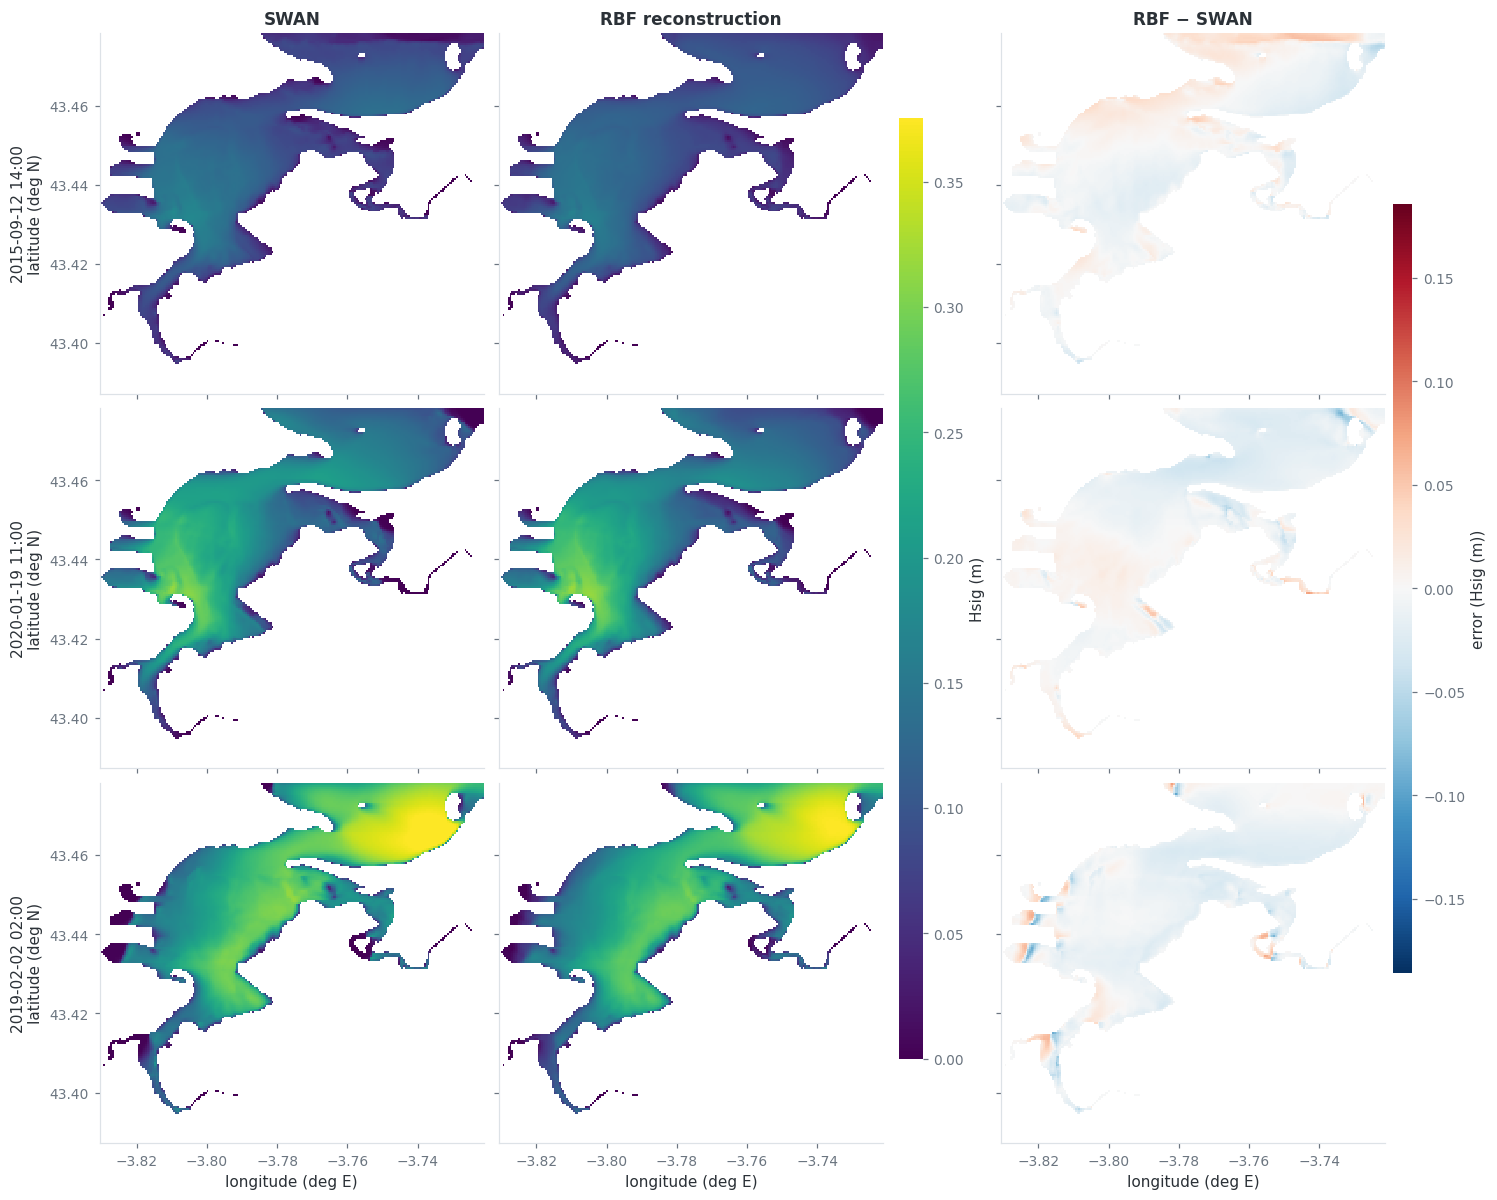

In [8]:
# The other end of the ranking, for reference.
plot_reconstruction_maps(
    truth,
    predicted,
    times=best,
    var_label=VAR_LABEL,
    vmin=0,
    vmax=float(np.nanpercentile(truth.sel(time=best).values, 99)),
);

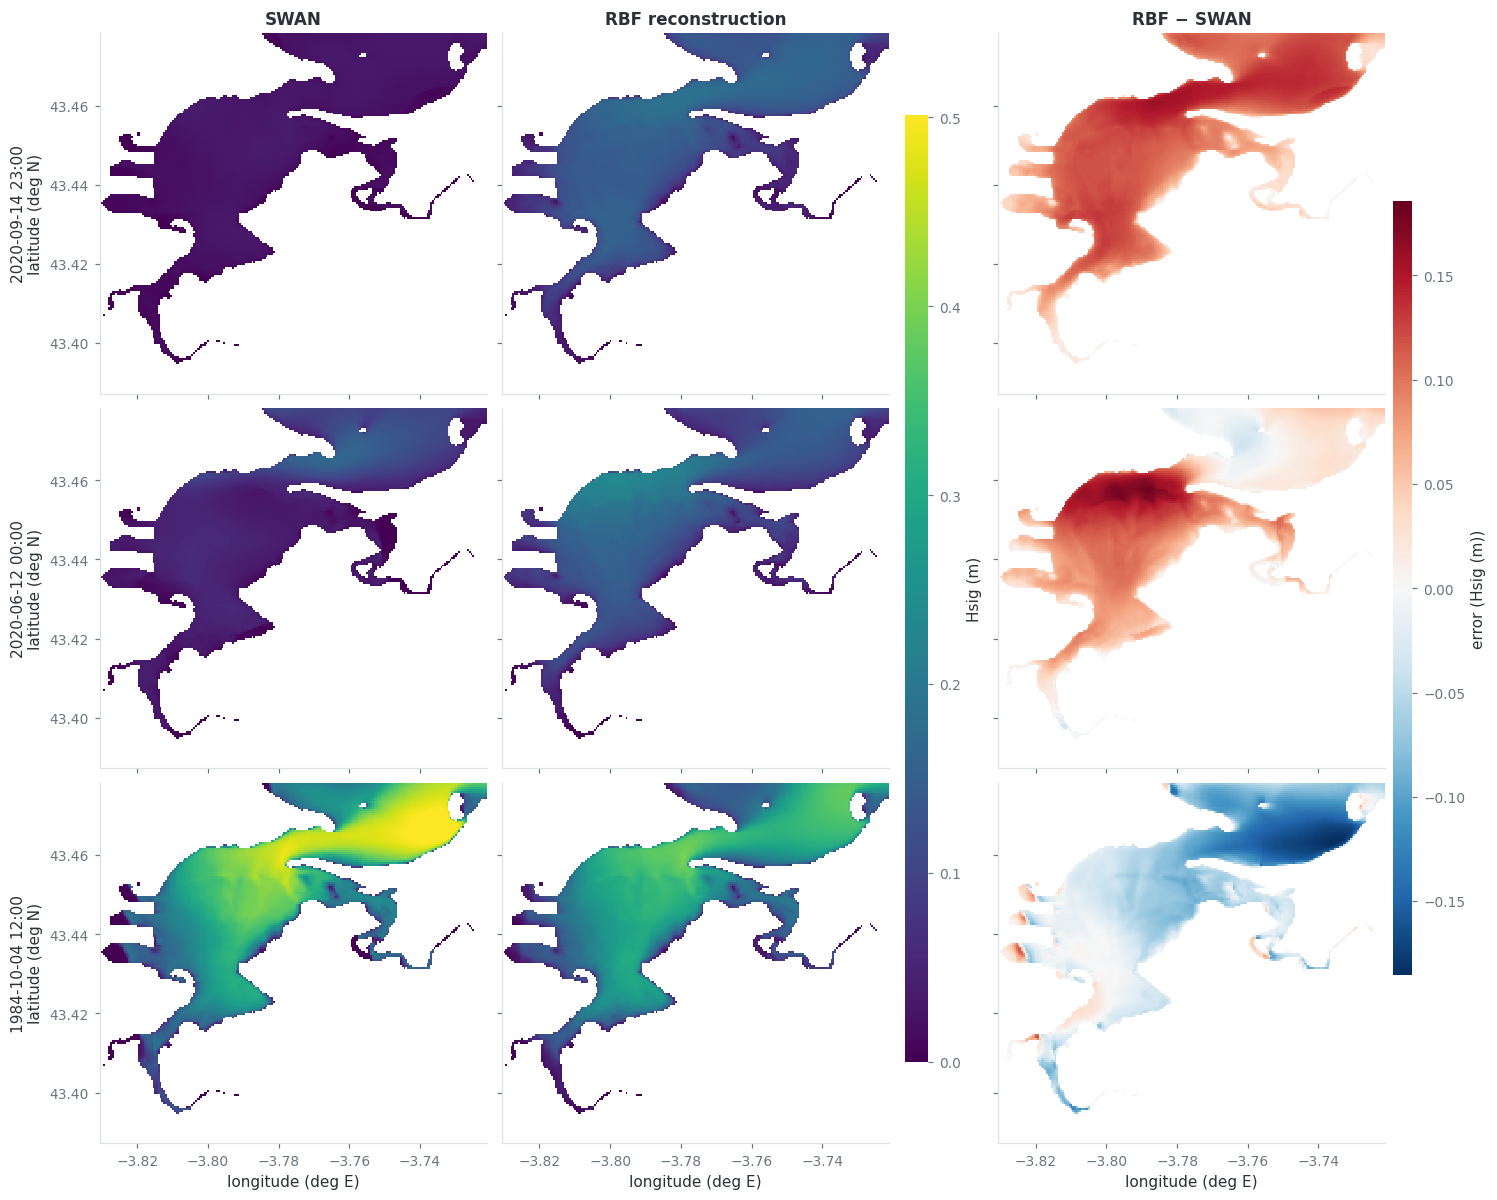

In [7]:
# Where the method shows its limits - the easy cases look identical and say
# little.
plot_reconstruction_maps(
    truth,
    predicted,
    times=worst,
    var_label=VAR_LABEL,
    vmin=0,
    # Scale to the cases actually shown, not to the whole test set: these three
    # are the worst, not the largest, and the full-set scale flattens them.
    vmax=float(np.nanpercentile(truth.sel(time=worst).values, 99)),
);

## 2 · The physical model — SWAN vs the tide gauge

The cases where SWAN was run *and* the gauge was recording. This is the ceiling:
the metamodel reproduces SWAN, so whatever SWAN misses here is missed downstream
too.

Two caveats belong with the number. The gauge measures the **total** sea state,
swell included, while these runs only carry the locally generated agitation — so
part of the gap is a difference in what is being measured, not model error. And
everything is at a single tide level.

In [9]:
gauge = xr.open_dataset(GAUGE_FILE)
gauge_times = pd.to_datetime(gauge.time.values)

swan_times = pd.to_datetime(waves.time.values)
both = swan_times.intersection(gauge_times)

# Select the point first: the SWAN time axis is not sorted, and method="nearest"
# applies to every dimension at once.
swan_at_gauge = waves[VAR].sel(lon=GAUGE_LON, lat=GAUGE_LAT, method="nearest")

chain = pd.concat(
    {
        "observed": gauge[GAUGE_VAR].sel(time=both.values).to_series(),
        "swan": swan_at_gauge.sel(time=both.values).to_series(),
        "rbf": reconstruct(both).sel(
            lon=GAUGE_LON, lat=GAUGE_LAT, method="nearest"
        ).to_series(),
    },
    axis=1,
).dropna()

unseen = chain.index.difference(train_times)
print(f"SWAN cases with a gauge record: {len(chain)}")
print(f"of which never used to train  : {len(unseen)}")

INFO:RBF:Reconstructing data using current sigma values.
INFO:RBF:Checking for NaNs in subset data
INFO:RBF:Preprocessing subset data
INFO:RBF:Normalizing subset data
INFO:RBF:Proposed max custom scaler for PC7 is lower than datapoint
INFO:RBF:Proposed min custom scaler for PC8 is bigger than datapoint
INFO:RBF:Proposed max custom scaler for PC8 is lower than datapoint
INFO:RBF:Subset data preprocessed successfully
INFO:RBF:Interpolating target variable PC1
INFO:RBF:Interpolating target variable PC2
INFO:RBF:Interpolating target variable PC3
INFO:RBF:Interpolating target variable PC4
INFO:RBF:Interpolating target variable PC5
INFO:RBF:Interpolating target variable PC6
INFO:RBF:Interpolating target variable PC7
INFO:RBF:Interpolating target variable PC8
INFO:RBF:Interpolating target variable PC9
INFO:RBF:Interpolating target variable PC10
INFO:RBF:Interpolating target variable PC11
INFO:RBF:Interpolating target variable PC12
INFO:RBF:Interpolating target variable PC13
INFO:RBF:Interpola

SWAN cases with a gauge record: 202
of which never used to train  : 79


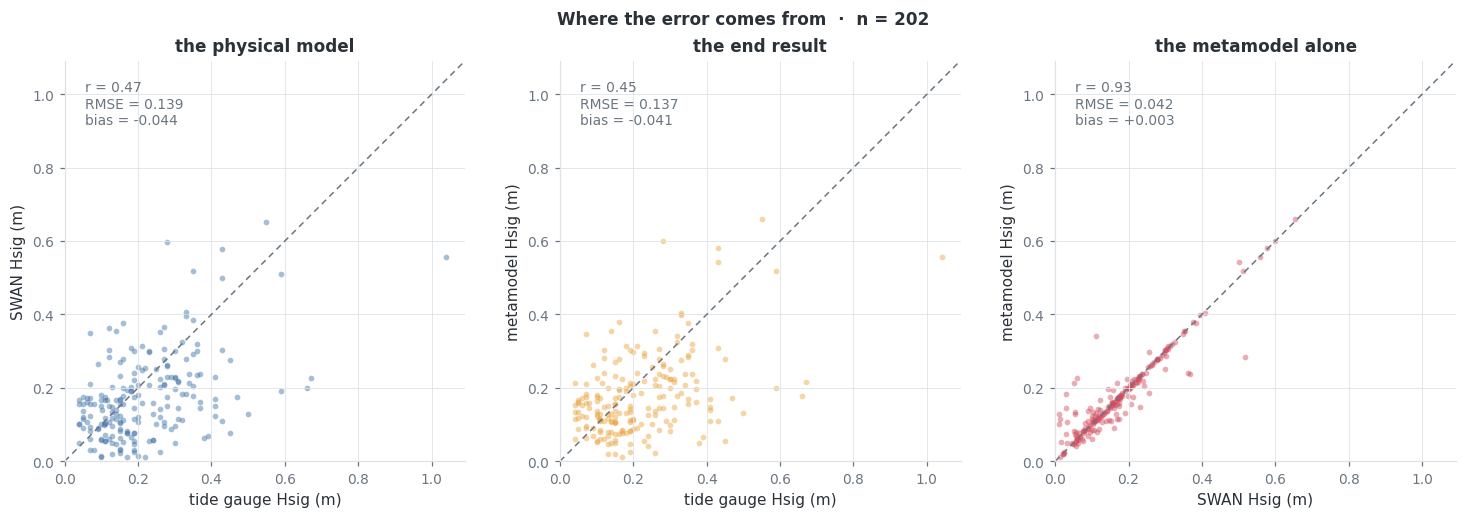

In [10]:
plot_error_chain(
    chain["observed"], chain["swan"], chain["rbf"], var_label=VAR_LABEL,
);

> ⚠️ Most of these cases were used to train the RBF, so the middle panel
> flatters the metamodel. The right-hand panel does not: reproducing SWAN is
> what the RBF was fitted to do, and the held-out figure from step 1 is the
> honest version of it.

## 3 · The end result — RBF vs the tide gauge

A harder test: times with a gauge record but no SWAN run, so the reconstruction
is the only estimate available. Training cases are excluded.

Two things make this a lower bound rather than a like-for-like comparison. The
gauge measures the **total** sea state, including the swell that enters the bay,
while these SWAN runs only carry the locally generated agitation. And everything
is rebuilt at a single tide level (`pos0m`) while the real record spans the whole
tidal range, which in a bay this shallow changes the agitation appreciably.

In [11]:
usable = gauge_times.intersection(pca_wind.pcs_df.index).difference(train_times)

print(f"gauge record   : {len(gauge_times):,} hours, "
      f"{gauge_times[0]:%Y-%m-%d} to {gauge_times[-1]:%Y-%m-%d}")
print(f"reconstructable: {len(usable):,} hours")

gauge record   : 151,438 hours, 2008-03-01 to 2025-12-31
reconstructable: 3,242 hours


In [12]:
at_gauge = reconstruct(usable).sel(
    lon=GAUGE_LON, lat=GAUGE_LAT, method="nearest"
)

print(f"gauge cell: lon={float(at_gauge.lon):.4f}, lat={float(at_gauge.lat):.4f}")

observed = gauge[GAUGE_VAR].sel(time=usable).to_series()
reconstructed = at_gauge.to_series()

INFO:RBF:Reconstructing data using current sigma values.
INFO:RBF:Checking for NaNs in subset data
INFO:RBF:Preprocessing subset data
INFO:RBF:Normalizing subset data
INFO:RBF:Proposed max custom scaler for PC2 is lower than datapoint
INFO:RBF:Subset data preprocessed successfully
INFO:RBF:Interpolating target variable PC1
INFO:RBF:Interpolating target variable PC2
INFO:RBF:Interpolating target variable PC3
INFO:RBF:Interpolating target variable PC4
INFO:RBF:Interpolating target variable PC5
INFO:RBF:Interpolating target variable PC6
INFO:RBF:Interpolating target variable PC7
INFO:RBF:Interpolating target variable PC8
INFO:RBF:Interpolating target variable PC9
INFO:RBF:Interpolating target variable PC10
INFO:RBF:Interpolating target variable PC11
INFO:RBF:Interpolating target variable PC12
INFO:RBF:Interpolating target variable PC13
INFO:RBF:Interpolating target variable PC14
INFO:RBF:Interpolating target variable PC15
INFO:RBF:Interpolating target variable PC16
INFO:RBF:Interpolating 

gauge cell: lon=-3.7899, lat=43.4600


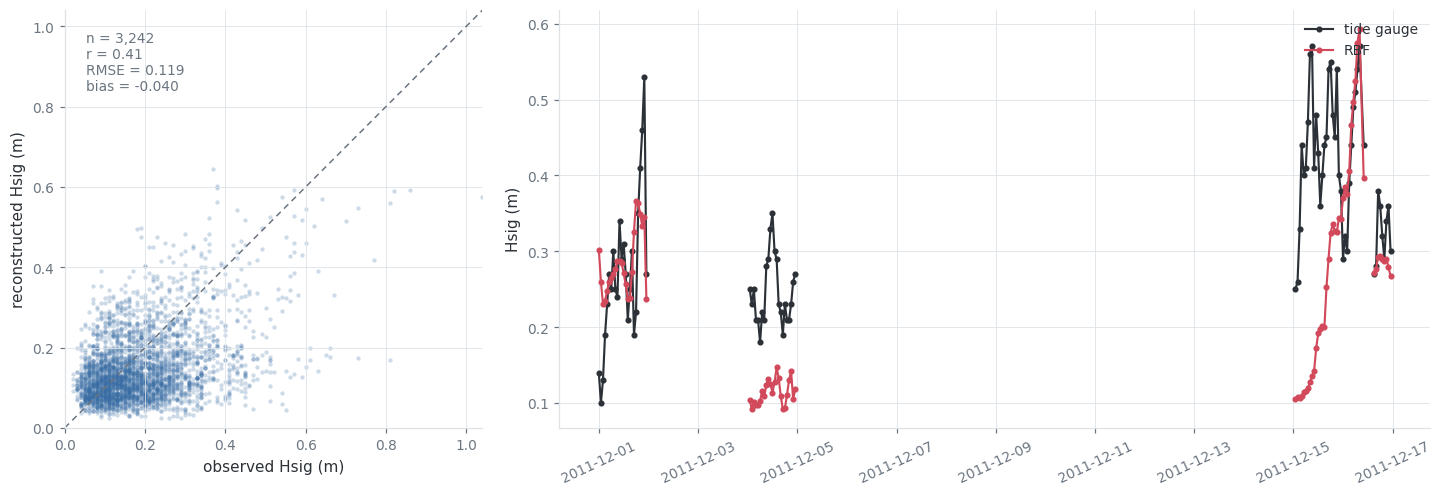

In [13]:
plot_gauge_validation(
    observed,
    reconstructed,
    var_label=VAR_LABEL,
);

## Summary

In [14]:
def score(a, b):
    d = pd.concat({"a": a, "b": b}, axis=1).dropna()
    return {
        "n": len(d),
        "corr": d.a.corr(d.b),
        "rmse": float(np.sqrt(((d.b - d.a) ** 2).mean())),
        "bias": float((d.b - d.a).mean()),
    }

pd.DataFrame(
    {
        "1 · metamodel (RBF vs SWAN)": score(chain["swan"], chain["rbf"]),
        "2 · physics (SWAN vs gauge)": score(chain["observed"], chain["swan"]),
        "3 · end result (RBF vs gauge)": score(observed, reconstructed),
    }
).T

,n,corr,rmse,bias
1 · metamodel (RBF vs SWAN),202.0,0.932075,0.042013,0.003058
2 · physics (SWAN vs gauge),202.0,0.466514,0.138546,-0.043632
3 · end result (RBF vs gauge),3242.0,0.407914,0.119034,-0.040499
